<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 3.1</h1>

The aim of this exercise is to apply Monte Carlo methods to the pricing of European call and put options within the Black–Scholes model. The option prices obtained numerically will be compared with the corresponding analytical Black–Scholes solutions, allowing us to test the accuracy of the Monte Carlo approach. In particular, the stochastic evolution of the asset price will be simulated according to geometric Brownian motion, and the option prices will be estimated from the corresponding payoffs at the expiration time.


### Financial Markets and the Black–Scholes Model

A market can be broadly defined as a place where buyers and sellers exchange goods or products. In a financial market, the traded products are financial assets, such as commodities and securities including bonds and stocks. The price of a given asset at time $t$ is denoted by the spot price $S(t)$.

Within the simplified framework considered in this exercise, a financial market is said to be efficient if three main conditions are satisfied:

* participants receive all relevant information about the market rapidly and in an understandable form;
* the market is sufficiently liquid, so that investors can easily buy or sell an asset;
* market frictions, such as transaction costs, are negligible compared with the volume of the transaction.

An efficient market incorporates all the relevant information about the future development of an asset into its current price. Consequently, knowing the past values of the price does not provide additional information about its future evolution once the current price is known. The price can therefore be modelled as a Markov process.

The Black–Scholes model assumes that the evolution of the asset price is stochastic and is described by a geometric Brownian motion (GBM), characterized by a constant risk-free interest rate $r$ and a constant volatility $\sigma$

$$
dS(t) = rS(t)dt + \sigma S(t)dW(t)
$$

Where $W(t)$ is the Weiner process. The model provides an analytical expression for the price of European options at a time $t<T$. In particular, the price of a European call option is

$$
C[S(t),t]=  S(t)N(d_1)- Ke^{-r(T-t)}N(d_2),
$$

while the price of a European put option is

$$
P[S(t),t] =S(t)\left[N(d_1)-1\right]- Ke^{-r(T-t)}\left[N(d_2)-1\right].
$$

Here, $K$ is the strike price, $T$ is the expiration time, and

$$
d_1=
\frac{
\ln\left(\frac{S(t)}{K}\right)
+
\left(r+\frac{\sigma^2}{2}\right)(T-t)
}{
\sigma\sqrt{T-t}
},
$$

with

$$
d_2=d_1-\sigma\sqrt{T-t}.
$$

The function $N(x)$ is the cumulative distribution function of a standard Gaussian random variable,

$$
N(x)=
\int_{-\infty}^{x}
dz,e^{-z^2/2}
=\frac{1}{2}
\left[
1+\operatorname{erf}\left(\frac{x}{\sqrt{2}}\right)
\right],
$$

where the error function is defined as

$$
\operatorname{erf}(x)=
\frac{2}{\sqrt{\pi}}
\int_0^x
dz,e^{-z^2}.
$$


In [2]:
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
import math

import scipy
from scipy.special import erf
from numpy import exp
from numpy.lib.scimath import log, sqrt

Let us begin to analytically evaluate the solutions of the Black-Scholes model.

In [3]:
# data
S0 = 100.
K = 100.
T = 1.
r = 0.1
sigma = 0.25
t=0

def N(x):
    return 0.5 * (1. + erf(x / sqrt(2.)))

def black_scholes(S0, K, T, r, sigma):
    d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)
    d2 = d1 - sigma * sqrt(T)
    C = S0 * N(d1) - K * exp(-r * T) * N(d2)
    P = S0 *(N(d1) - 1.) - K * exp(-r * T) * (N(d2)-1.)
    return C, P

if __name__ == "__main__":
    call, put = black_scholes(S0, K, T, r, sigma)
    print(" == BLACK-SCHOLES ==")
    print("call: ", call)
    print("put: ", put)

 == BLACK-SCHOLES ==
call:  14.975790778311286
put:  5.4595325819072364


### Monte Carlo simulation of option prices

To evaluate the prices of European call and put options, two different Monte Carlo sampling methods are considered. The first method is the **direct sampling**, in which $N$ independent realizations of the final asset price $S(T)$ are generated directly from the analytical solution of the geometric Brownian motion,

$$
S_T=S_0
\exp\left[
\left(r-\frac{\sigma^2}{2}\right)T+\sigma W
\right],
$$

where $W$ is a Gaussian random variable with zero mean and variance $T$,

$$
W\sim\mathcal{N}(0,T).
$$

The second method is the **discrete sampling**, in which the time interval $[0,T]$ is divided into 100 equal subintervals. The evolution of the asset price is then simulated step by step according to the discretized geometric Brownian motion,

$$
S(t_{i+1})=S(t_i)
\exp\left[
\left(r-\frac{\sigma^2}{2}\right)\Delta t
+
\sigma\sqrt{\Delta t},Z_i
\right],
$$

where

$$
\Delta t=\frac{T}{100},
$$

and $Z_i$ are independent standard Gaussian random variables. After the 100 time steps, the resulting value $S(t_{100})=S(T)$ is used to evaluate the option payoff.

For both sampling methods, the prices of the options are estimated by calculating the progressive averages of the discounted payoff. For a European call option, the discounted payoff is

$$
C=e^{-rT}\max(0,S_T-K),
$$

while for a European put option it is

$$
P=e^{-rT}\max(0,K-S_T),
$$

where $K$ is the strike price. The progressive averages and their statistical uncertainties are evaluated using the data blocking method. In this exercise, a total of $M=100000$ simulations are performed and divided into $N=100$ blocks.


In [4]:
dc_ave = np.loadtxt('direct_call_ave_prog.txt')
dc_err = np.loadtxt('direct_call_err_prog.txt')
dp_ave = np.loadtxt('direct_put_ave_prog.txt')
dp_err = np.loadtxt('direct_put_err_prog.txt')
dic_ave = np.loadtxt('discrete_call_ave_prog.txt')
dic_err = np.loadtxt('discrete_call_err_prog.txt')
dip_ave = np.loadtxt('discrete_put_ave_prog.txt')
dip_err = np.loadtxt('discrete_put_err_prog.txt')

In [5]:
M = 100000
N = 100
L = int(M/N)
x = np.arange(N)
x *= L

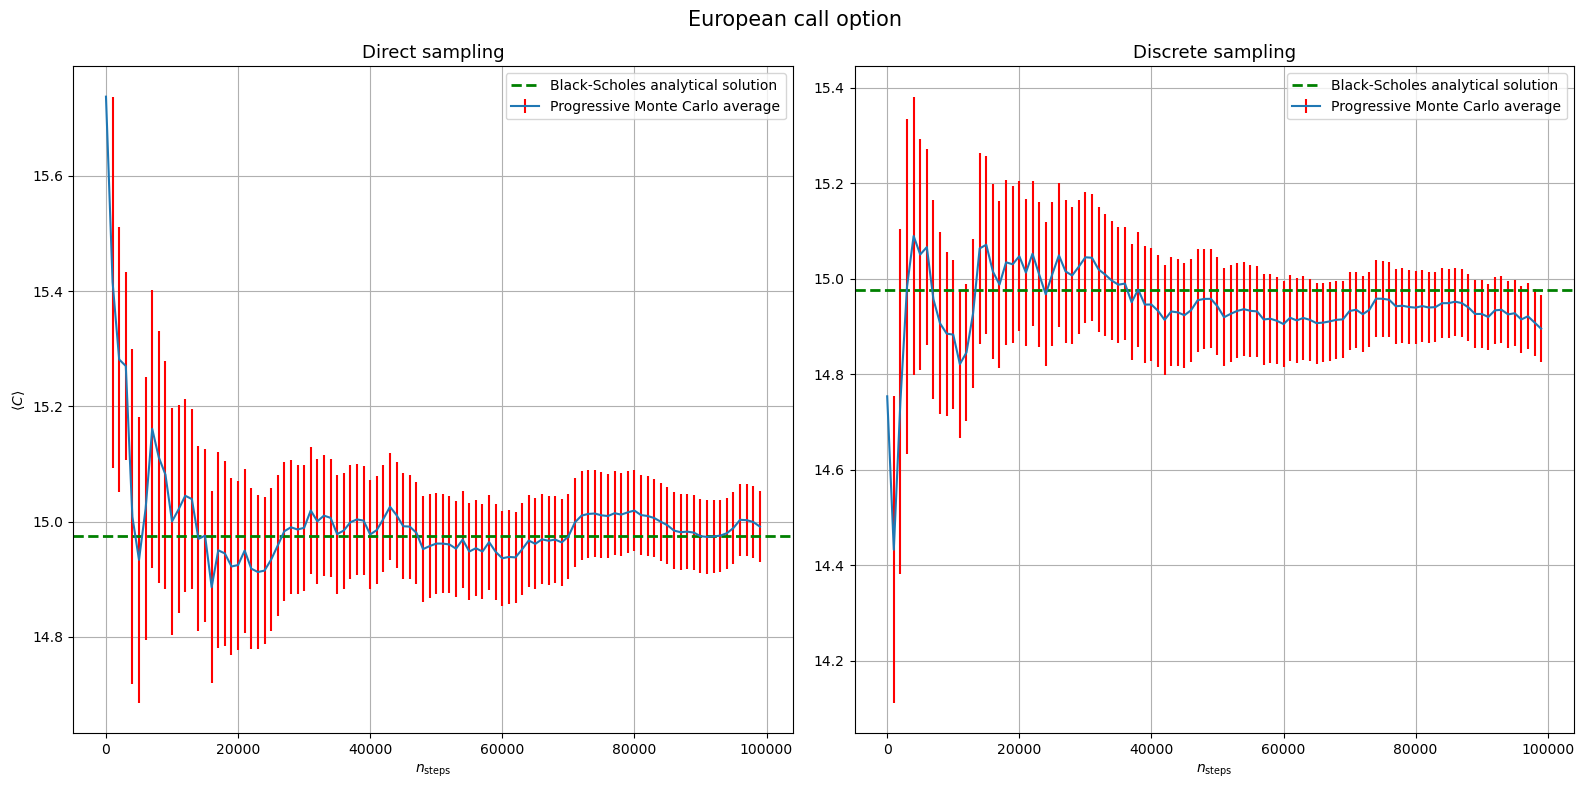

In [13]:
fig, axs1 = plt.subplots(1, 2, figsize=(16, 8))

datasets = [dc_ave, dic_ave]
errorsets = [dc_err, dic_err]
titles = [
    "Direct sampling",
    "Discrete sampling",
]

for ax, data, error, title in zip(axs1, datasets, errorsets, titles):

    ax.errorbar(
        x, data,
        yerr=error,
        ecolor='red',
        label='Progressive Monte Carlo average'
    )

    ax.axhline(
        y=call,
        color='green',
        linestyle='--',
        linewidth=2,
        label='Black-Scholes analytical solution'
    )

    ax.grid(True)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(r"$n_{\mathrm{steps}}$")
    ax.legend()

axs1[0].set_ylabel(r"$\langle C \rangle$")
plt.suptitle("European call option", fontsize=15)

plt.tight_layout()
plt.show()

**Figure 1.** Progressive Monte Carlo averages of the discounted call payoff as a function of the number of simulation steps, obtained using discrete sampling (right) and direct sampling (left), together with the analytical Black–Scholes solution shown as a horizontal dashed line.


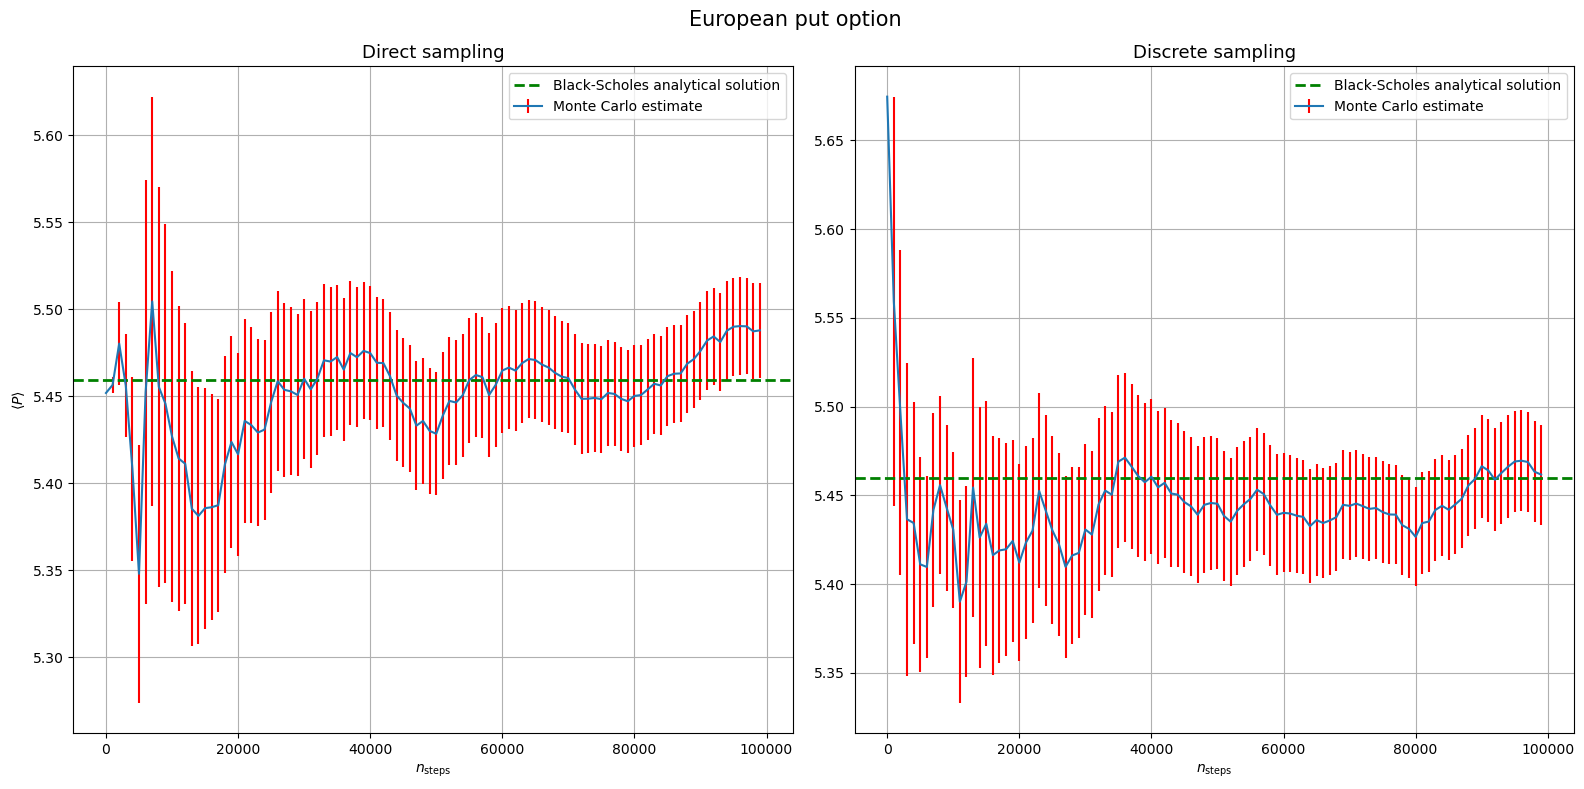

In [14]:
fig, axs2 = plt.subplots(1, 2, figsize=(16, 8))

datasets = [dp_ave, dip_ave]
errorsets = [dp_err, dip_err]
titles = [
    "Direct sampling",
    "Discrete sampling",
]

for ax, data, error, title in zip(axs2, datasets, errorsets, titles):

    ax.errorbar(
        x, data,
        yerr=error,
        markersize=3,
        ecolor='red',
        label='Monte Carlo estimate'
    )

    ax.axhline(
        y=put,
        color='green',
        linestyle='--',
        linewidth=2,
        label='Black-Scholes analytical solution'
    )

    ax.grid(True)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(r"$n_{\mathrm{steps}}$")
    ax.legend()

axs2[0].set_ylabel(r"$\langle P \rangle$")
plt.suptitle("European put option", fontsize=15)

plt.tight_layout()
plt.show()

**Figure 2.** Progressive Monte Carlo averages of the discounted put payoff as a function of the number of simulation steps, obtained using discrete sampling (right) and direct sampling (left), together with the analytical Black–Scholes solution shown as a horizontal dashed line.


### Results and conclusions

The results obtained with the Monte Carlo simulations are in good agreement with the analytical Black–Scholes predictions for both European call and put options. The analytical values are$C=14.97579$ for the call option and$P=5.45953$ for the put option.

For the call option, the direct sampling gives

$$
C_{\mathrm{direct}}=14.99141\pm0.06157,
$$

while the discrete sampling gives

$$
C_{\mathrm{discrete}}=14.89565\pm0.07019.
$$

Both estimates are compatible with the analytical result within their statistical uncertainties. Similarly, for the put option, the direct sampling gives

$$
P_{\mathrm{direct}}=5.48786\pm0.02726
$$

and the discrete sampling gives

$$
P_{\mathrm{discrete}}=5.46172\pm0.02812,
$$

showing an excellent agreement with the Black–Scholes value.

Overall, the results confirm the validity of the Monte Carlo approach for pricing European options within the Black–Scholes model. Both direct and discrete sampling reproduce the analytical prices within the expected statistical fluctuations, with comparable uncertainties.
